# Phase 1: Environment & Data Loading

In this step, we prepare the Python environment and bring the raw data into a structure we can manipulate.

## 1.1 Python Imports

We start by importing the libraries that will do the heavy lifting.

In [1]:
# pandas: The industry standard for data manipulation (think of it as Excel for Python).
import pandas as pd

# matplotlib & seaborn: These are used for data visualization (charts and graphs).
import matplotlib.pyplot as plt
import seaborn as sns

# os: This allows Python to interact with your Ubuntu file system.
import os

## 1.2 Loading the Dataset

We use read_csv to open the file. Note the encoding parameter; standard text is usually UTF-8, but this specific dataset was saved in an older format called latin-1.

In [8]:
# Load the dataset from your local directory.
# We use encoding='latin-1' because the file contains special characters that standard UTF-8 can't read.
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Display the first 5 rows to see what the raw data looks like.
print("--- Raw Data Preview ---")
print(df.head())

--- Raw Data Preview ---
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


# Phase 2: Data Wrangling (Cleaning the Structure)

Before we clean the text, we must clean the table. Raw datasets often have "ghost columns" (empty columns) or confusing names.

## 2.1 Removing "Ghost" Columns

We notice that the dataset includes three empty columns (Unnamed: 2, 3, and 4) due to commas in the original text messages. We must drop them.

In [9]:
# The 'drop' function removes columns we don't need. 
# axis=1 tells Pandas to look at columns, not rows.
# inplace=True makes the change directly to our 'df' variable.
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

# Rename the columns to something logical. 
# 'v1' becomes 'label' (our target) and 'v2' becomes 'text' (our input).
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

print("\n--- Cleaned Column Names ---")
print(df.head())


--- Cleaned Column Names ---
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 2.2 Handling Categorical Data (Label Encoding)

Machine learning models cannot read the words "spam" or "ham." They only understand numbers. We will convert these labels into $0$ and $1$.

In [10]:
# We map 'ham' to 0 and 'spam' to 1.
# 0 usually represents the "normal" class, and 1 represents the "anomaly" or target class.
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("\n--- Labels Converted to Numbers ---")
print(df[['label', 'label_num']].head())


--- Labels Converted to Numbers ---
  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


# Phase 3: Exploratory Data Analysis (EDA)

This fulfills Step 2 (Developing a Strategy) of your assessment. We need to "see" the data to understand the challenges.

## 3.1 Visualizing Class Imbalance

We need to know if we have enough spam examples to train the model.

/tmp/ipykernel_40545/3461309764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


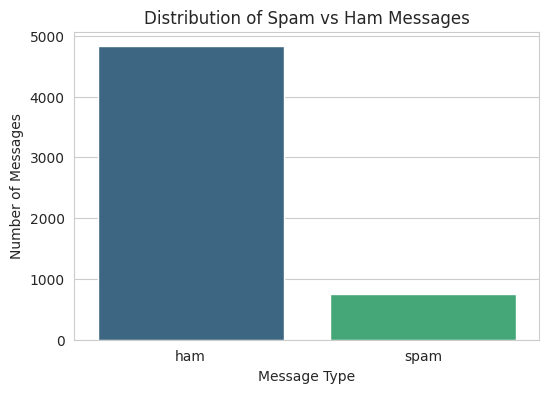


--- Class Percentages ---
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [13]:
# Set the visual style of our charts.
sns.set_style('whitegrid')

# Create a count plot to see the distribution of Ham vs Spam.
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

# Calculate the exact percentages for the report.
print("\n--- Class Percentages ---")
print(df['label'].value_counts(normalize=True) * 100)

# Phase 4: Text Pre-processing

In NLP, raw text is "noisy." To help the model find patterns, we must standardize the text. This involves converting to lowercase, removing punctuation, and removing "stopwords" (common words like 'the' or 'is' that don't help classify spam).